In [1]:
# Komórka 1: Importy i ustawienia

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
import seaborn as sns
np.random.seed(42)
torch.manual_seed(42)
print("Importy załadowane, seed ustawiony.")
cuda = torch.cuda.is_available()
print("CUDA dostępne:", cuda)

Importy załadowane, seed ustawiony.
CUDA dostępne: False


In [2]:

# Komórka 2: Implementacja LSTM i Attention w numpy
class LSTM:
    def __init__(self, input_size, hidden_size):
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.Wf = np.random.randn(hidden_size, input_size + hidden_size) * 0.01
        self.bf = np.zeros((hidden_size, 1))
        self.Wi = np.random.randn(hidden_size, input_size + hidden_size) * 0.01
        self.bi = np.zeros((hidden_size, 1))
        self.Wc = np.random.randn(hidden_size, input_size + hidden_size) * 0.01
        self.bc = np.zeros((hidden_size, 1))
        self.Wo = np.random.randn(hidden_size, input_size + hidden_size) * 0.01
        self.bo = np.zeros((hidden_size, 1))
    def sigmoid(self, x):
        return 1 / (1 + np.exp(-x))
    def tanh(self, x):
        return np.tanh(x)
    def forward(self, x, h_prev, c_prev):
        concat = np.vstack((h_prev, x))
        ft = self.sigmoid(np.dot(self.Wf, concat) + self.bf)
        it = self.sigmoid(np.dot(self.Wi, concat) + self.bi)
        c_tilde = self.tanh(np.dot(self.Wc, concat) + self.bc)
        ct = ft * c_prev + it * c_tilde
        ot = self.sigmoid(np.dot(self.Wo, concat) + self.bo)
        ht = ot * self.tanh(ct)
        return ht, ct
    def forward_sequence(self, x_seq, h0=None, c0=None):
        seq_len = x_seq.shape[0]
        h = np.zeros((self.hidden_size, 1)) if h0 is None else h0
        c = np.zeros((self.hidden_size, 1)) if c0 is None else c0
        outputs = []
        for t in range(seq_len):
            x_t = x_seq[t].reshape(-1, 1)
            h, c = self.forward(x_t, h, c)
            outputs.append(h)
        outputs = np.concatenate(outputs, axis=1)
        return outputs, h, c

class LSTMWithAttention(LSTM):
    def __init__(self, input_size, hidden_size):
        super().__init__(input_size, hidden_size)
        self.W_a = np.random.randn(1, hidden_size) * 0.01
        self.b_a = np.zeros((1, 1))
    def softmax(self, x):
        exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
        return exp_x / np.sum(exp_x, axis=1, keepdims=True)
    def forward_with_attention(self, x_seq, h0=None, c0=None):
        outputs, h_final, c_final = self.forward_sequence(x_seq, h0, c0)
        scores = np.tanh(np.dot(self.W_a, outputs) + self.b_a)
        att_weights = self.softmax(scores)
        context_vector = np.sum(outputs * att_weights, axis=1, keepdims=True)
        return context_vector, att_weights, h_final, c_final

print("LSTM i LSTMWithAttention zaimplementowane.")

LSTM i LSTMWithAttention zaimplementowane.


In [3]:
# Komórka 3: Funkcje do tokenizacji i BPE
def convert_text_to_bytes(text):
    return list(map(int, text.encode('utf-8')))
def merge_pair_single(token_list, pair_to_merge, new_token):
    new_list, i = [], 0
    while i < len(token_list):
        if i < len(token_list) - 1 and (token_list[i], token_list[i+1]) == pair_to_merge:
            new_list.append(new_token); i += 2
        else:
            new_list.append(token_list[i]); i += 1
    return new_list
def iterative_merge(token_list, num_iterations, start_token=256):
    new_token = start_token
    current_tokens = token_list
    for _ in range(num_iterations):
        stats = {}
        for pair in zip(current_tokens, current_tokens[1:]):
            stats[pair] = stats.get(pair, 0) + 1
        if not stats: break
        most_common_pair = max(stats, key=stats.get)
        current_tokens = merge_pair_single(current_tokens, most_common_pair, new_token)
        new_token += 1
    return current_tokens

print("Funkcje tokenizacji i BPE gotowe.")


Funkcje tokenizacji i BPE gotowe.


In [4]:
# Komórka 4: Implementacja Generatora i Dyskryminatora (PyTorch)
class LSTMGeneratorPyTorch(nn.Module):
    def __init__(self, latent_dim, hidden_dim, embedding_dim, seq_len):
        super().__init__()
        self.seq_len = seq_len
        self.hidden_dim = hidden_dim
        self.fc = nn.Linear(latent_dim, hidden_dim * seq_len)
        self.lstm = nn.LSTM(hidden_dim, hidden_dim, num_layers=1, batch_first=True)
        self.output_layer = nn.Linear(hidden_dim, embedding_dim)
    def forward(self, z):
        x = self.fc(z)
        x = x.view(-1, self.seq_len, self.hidden_dim)
        lstm_out, _ = self.lstm(x)
        output = self.output_layer(lstm_out)
        return output

class DiscriminatorPyTorch(nn.Module):
    def __init__(self, embedding_dim, hidden_dim):
        super().__init__()
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, num_layers=1, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_dim * 2, 1)
    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        features = torch.mean(lstm_out, dim=1)
        output = self.fc(features)
        return torch.sigmoid(output)

print("Generator i Dyskryminator gotowe.")

Generator i Dyskryminator gotowe.


In [5]:
# Komórka 5: Wczytanie i podział danych
df = pd.read_csv('fake_or_real_news.csv')[['text', 'title', 'label']]
print("Wczytano dane:", df.shape)
df_real_all = df[df['label'] == 'REAL']
df_fake_all = df[df['label'] == 'FAKE']
dfReal = df_real_all.sample(frac=0.5, random_state=42)
df_remaining_real = df_real_all.drop(dfReal.index)
dfFake = pd.concat([df_fake_all, df_remaining_real]).sample(frac=1, random_state=42).reset_index(drop=True)
dfFake_fake = dfFake[dfFake['label'] == 'FAKE'].sample(frac=0.5, random_state=42)
dfFake_real = dfFake[dfFake['label'] != 'FAKE']
dfFake = pd.concat([dfFake_real, dfFake_fake]).sample(frac=0.5, random_state=42).reset_index(drop=True)
dfReal = dfReal.reset_index(drop=True)
dfFake = dfFake.reset_index(drop=True)
dfReal = dfReal.drop(columns=['label'])
dfFake = dfFake.drop(columns=['label'])
print("Podział na dfReal:", len(dfReal), "dfFake:", len(dfFake))

Wczytano dane: (6335, 3)
Podział na dfReal: 1586 dfFake: 1584


In [6]:
# Komórka 6: Tokenizacja i BPE
opt_steps = 5
for df_ in [dfReal, dfFake]:
    df_['title_bytes'] = df_['title'].apply(convert_text_to_bytes)
    df_['text_bytes'] = df_['text'].apply(convert_text_to_bytes)
    df_['title_bytes'] = df_['title_bytes'].apply(lambda t: iterative_merge(t, opt_steps))
    df_['text_bytes'] = df_['text_bytes'].apply(lambda t: iterative_merge(t, opt_steps))
print("Tokenizacja i BPE zakończone.")


Tokenizacja i BPE zakończone.


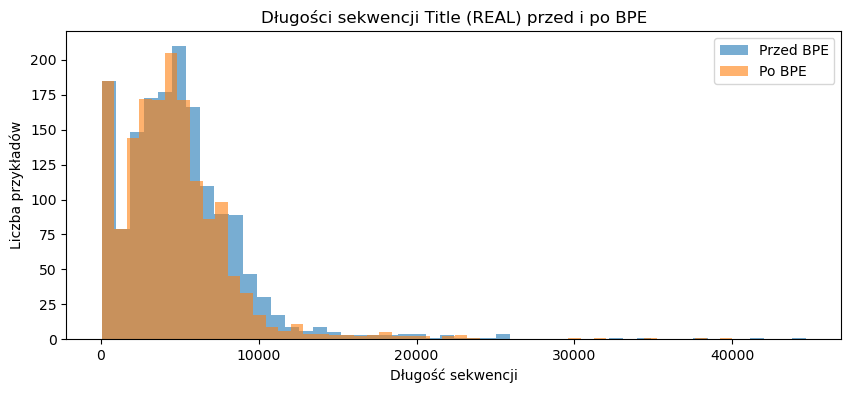

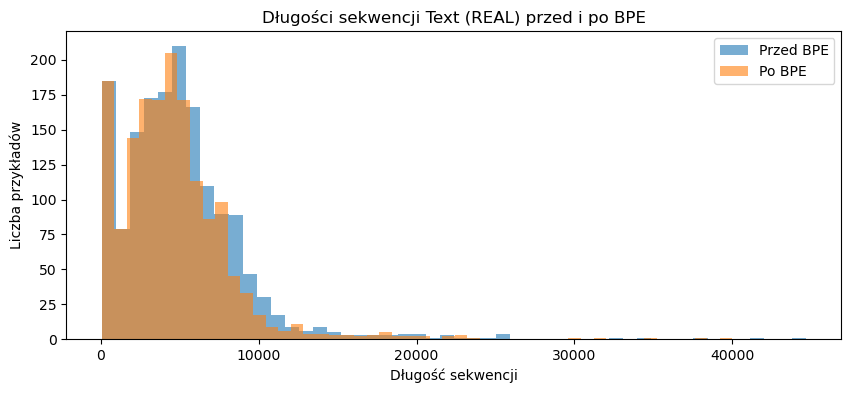

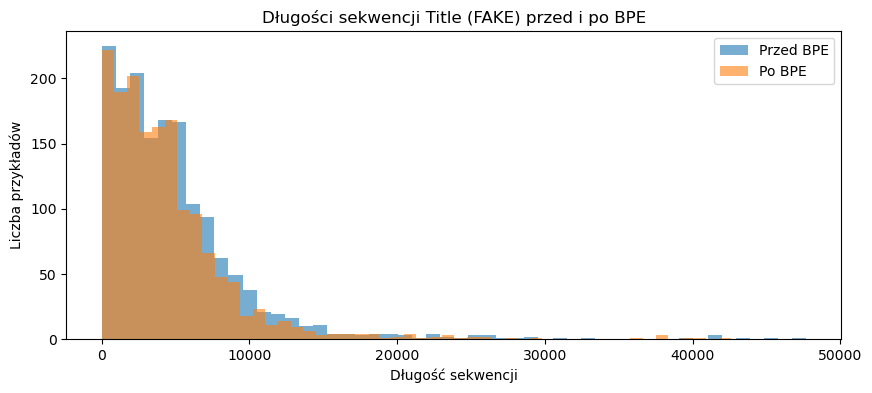

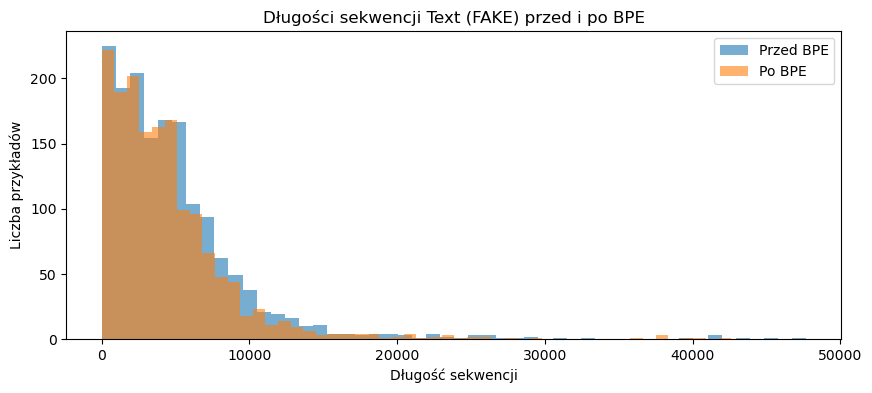

In [7]:
# Oblicz długości przed i po BPE dla tytułów i tekstów (dla obu klas)
def get_lengths(df, col_bytes, col_bpe):
    col_bytes = 'text' 
    col_bpe = 'text_bytes'
    raw_lengths = df[col_bytes].apply(lambda x: len(x.encode('utf-8')))
    bpe_lengths = df[col_bpe].apply(len)
    return raw_lengths, bpe_lengths

# Zbierz dane dla obu DataFrame (dfReal, dfFake)
for df_, label in zip([dfReal, dfFake], ["REAL", "FAKE"]):
    for col_base, col_bpe, label_name in [
        ('title', 'title_bytes', 'Title'), 
        ('text', 'text_bytes', 'Text')
    ]:
        raw_lens, bpe_lens = get_lengths(df_, col_base, col_bpe)
        plt.figure(figsize=(10,4))
        plt.hist(raw_lens, bins=50, alpha=0.6, label='Przed BPE')
        plt.hist(bpe_lens, bins=50, alpha=0.6, label='Po BPE')
        plt.title(f'Długości sekwencji {label_name} ({label}) przed i po BPE')
        plt.xlabel('Długość sekwencji')
        plt.ylabel('Liczba przykładów')
        plt.legend()
        plt.show()

In [8]:
# Komórka 7: Embedding
all_tokens = set()
for df_ in [dfReal, dfFake]:
    for col in ['title_bytes', 'text_bytes']:
        for tokens in df_[col]:
            all_tokens.update(tokens)
num_embeddings = max(all_tokens) + 1
embedding_dim = 5
embedding_layer = nn.Embedding(num_embeddings, embedding_dim)
print(f"Liczba unikalnych tokenów: {num_embeddings}")

def embed_text(tokens):
    token_tensor = torch.tensor(tokens, dtype=torch.long)
    with torch.no_grad():
        embedded = embedding_layer(token_tensor)
    return embedded.cpu().numpy()

for df_ in [dfReal, dfFake]:
    df_['embedded_text'] = df_['text_bytes'].apply(embed_text)
    df_['embedded_title'] = df_['title_bytes'].apply(embed_text)
print("Embeddingi wygenerowane.")


Liczba unikalnych tokenów: 261
Embeddingi wygenerowane.


In [9]:
# Komórka 8: LSTM z attention na embeddingach
input_size = embedding_dim
hidden_size = 20
lstm_model = LSTMWithAttention(input_size, hidden_size)
def get_final_hidden(seq):
    _, _, h_final, _ = lstm_model.forward_with_attention(seq)
    return h_final.squeeze()
for df_ in [dfReal, dfFake]:
    df_['final_hidden_state_text'] = df_['embedded_text'].apply(get_final_hidden)
    df_['final_hidden_state_title'] = df_['embedded_title'].apply(get_final_hidden)
print("Końcowe stany ukryte z LSTM z attention wyciągnięte.")

Końcowe stany ukryte z LSTM z attention wyciągnięte.


In [10]:
# Komórka 9: Łączenie i normalizacja embeddingów
real_embeds = np.stack([
    np.stack(dfReal['final_hidden_state_title'].to_numpy()),
    np.stack(dfReal['final_hidden_state_text'].to_numpy())
], axis=1)
fake_embeds = np.stack([
    np.stack(dfFake['final_hidden_state_title'].to_numpy()),
    np.stack(dfFake['final_hidden_state_text'].to_numpy())
], axis=1)
real_embeds = torch.tensor(real_embeds, dtype=torch.float32)
fake_embeds = torch.tensor(fake_embeds, dtype=torch.float32)
layer_norm = nn.LayerNorm(real_embeds.shape[2:])
with torch.no_grad():
    real_embeds = layer_norm(real_embeds)
    fake_embeds = layer_norm(fake_embeds)
print("Embeddingi połączone i znormalizowane.")
print("real_embeds shape:", real_embeds.shape, "fake_embeds shape:", fake_embeds.shape)

Embeddingi połączone i znormalizowane.
real_embeds shape: torch.Size([1586, 2, 20]) fake_embeds shape: torch.Size([1584, 2, 20])


In [11]:
# Komórka 10: Przygotowanie DataLoaderów
batch_size = 16
dataset_real = TensorDataset(real_embeds)
dataloader_real = DataLoader(dataset_real, batch_size=batch_size, shuffle=True)
dataset_fake = TensorDataset(fake_embeds)
dataloader_fake = DataLoader(dataset_fake, batch_size=batch_size, shuffle=True)
print("DataLoadery przygotowane.")

DataLoadery przygotowane.


In [12]:
# Komórka 11: Inicjalizacja modeli, optymalizatorów i loss
latent_dim = 100
hidden_dim = 128
seq_len = real_embeds.size(1)
final_embedding_dim = real_embeds.size(2)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
generator = LSTMGeneratorPyTorch(latent_dim, hidden_dim, final_embedding_dim, seq_len).to(device)
discriminator = DiscriminatorPyTorch(final_embedding_dim, hidden_dim).to(device)
optimizer_G = optim.Adam(generator.parameters(), lr=0.0002)
optimizer_D = optim.Adam(discriminator.parameters(), lr=0.0002)
criterion = nn.BCELoss()
print("Modele GAN gotowe.")

Modele GAN gotowe.


In [13]:
# Komórka 12: Funkcja train_step
def train_step(real_batch):
    batch_size = real_batch.size(0)
    valid = torch.ones(batch_size, 1, device=device)
    fake = torch.zeros(batch_size, 1, device=device)
    optimizer_D.zero_grad()
    real_preds = discriminator(real_batch)
    loss_real = criterion(real_preds, valid)
    z = torch.randn(batch_size, latent_dim, device=device)
    with torch.no_grad():
        gen_batch = generator(z)
    fake_preds = discriminator(gen_batch)
    loss_fake = criterion(fake_preds, fake)
    loss_D = 0.5 * (loss_real + loss_fake)
    loss_D.backward()
    optimizer_D.step()
    optimizer_G.zero_grad()
    z = torch.randn(batch_size, latent_dim, device=device)
    gen_batch = generator(z)
    pred_gen = discriminator(gen_batch)
    loss_G = criterion(pred_gen, valid)
    loss_G.backward()
    optimizer_G.step()
    return loss_D.item(), loss_G.item()
print("train_step gotowe.")

train_step gotowe.


In [14]:
# Komórka 13: Trening GANa
num_epochs = 2100
losses_D, losses_G = [], []
for epoch in range(num_epochs):
    epoch_loss_D = 0
    epoch_loss_G = 0
    n_batches = 0
    for real_batch_tuple in dataloader_real:
        real_batch = real_batch_tuple[0].to(device)
        loss_D, loss_G = train_step(real_batch)
        epoch_loss_D += loss_D
        epoch_loss_G += loss_G
        n_batches += 1
    if n_batches > 0:
        epoch_loss_D /= n_batches
        epoch_loss_G /= n_batches
    losses_D.append(epoch_loss_D)
    losses_G.append(epoch_loss_G)
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{num_epochs} - Loss_D: {epoch_loss_D:.4f}, Loss_G: {epoch_loss_G:.4f}")
print("Trening zakończony.")


Epoch 10/2100 - Loss_D: 0.5482, Loss_G: 0.9382
Epoch 20/2100 - Loss_D: 0.5966, Loss_G: 0.9215
Epoch 30/2100 - Loss_D: 0.6312, Loss_G: 0.7747
Epoch 40/2100 - Loss_D: 0.6104, Loss_G: 0.8385
Epoch 50/2100 - Loss_D: 0.6705, Loss_G: 0.7937
Epoch 60/2100 - Loss_D: 0.6659, Loss_G: 0.8131
Epoch 70/2100 - Loss_D: 0.6665, Loss_G: 0.7543
Epoch 80/2100 - Loss_D: 0.6747, Loss_G: 0.7426
Epoch 90/2100 - Loss_D: 0.6472, Loss_G: 0.7736
Epoch 100/2100 - Loss_D: 0.6716, Loss_G: 0.7465
Epoch 110/2100 - Loss_D: 0.6529, Loss_G: 0.7650
Epoch 120/2100 - Loss_D: 0.6557, Loss_G: 0.7590
Epoch 130/2100 - Loss_D: 0.6673, Loss_G: 0.7639
Epoch 140/2100 - Loss_D: 0.6337, Loss_G: 0.8051
Epoch 150/2100 - Loss_D: 0.6454, Loss_G: 0.7923
Epoch 160/2100 - Loss_D: 0.6563, Loss_G: 0.7732
Epoch 170/2100 - Loss_D: 0.6524, Loss_G: 0.7712
Epoch 180/2100 - Loss_D: 0.6521, Loss_G: 0.7598
Epoch 190/2100 - Loss_D: 0.6679, Loss_G: 0.7412
Epoch 200/2100 - Loss_D: 0.6704, Loss_G: 0.7338
Epoch 210/2100 - Loss_D: 0.6541, Loss_G: 0.7598
E

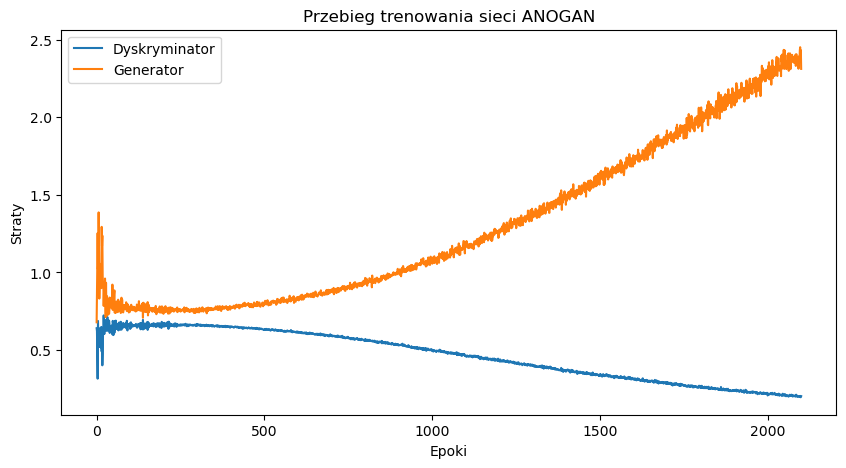

In [15]:
# Komórka 14: Wykres strat
plt.figure(figsize=(10, 5))
plt.plot(losses_D, label='Dyskryminator')
plt.plot(losses_G, label='Generator')
plt.xlabel('Epoki')
plt.ylabel('Straty')
plt.legend()
plt.title('Przebieg trenowania sieci ANOGAN')
plt.show()

In [16]:
def detect_anomaly(data, generator, discriminator):
    lambda_param = 0.1
    batch_size = data.size(0)
    anomaly_scores = []
    discriminator.eval()   # dyskryminator zawsze eval
    for i in range(batch_size):
        sample = data[i:i+1].to(device)
        generator.train()    # <-- KLUCZOWE!
        z = torch.randn(1, latent_dim, device=device, requires_grad=True)
        z_optimizer = optim.Adam([z], lr=0.01)
        for _ in range(100):
            z_optimizer.zero_grad()
            gen_sample = generator(z)
            loss = torch.nn.MSELoss()(gen_sample, sample)
            loss.backward()
            z_optimizer.step()
        generator.eval()     # <-- wracamy do eval na koniec dla bezpieczeństwa
        with torch.no_grad():
            gen_sample = generator(z)
            residual_loss = torch.nn.MSELoss()(gen_sample, sample)
            discriminator_score = discriminator(sample)
            anomaly_score = (1 - discriminator_score) + lambda_param * residual_loss
            anomaly_scores.append(anomaly_score.item())
        if (i+1) % 10 == 0 or i == 0:
            print(f"  Detekcja anomalii dla próbki {i+1}/{batch_size}, score: {anomaly_scores[-1]:.4f}")
    return np.array(anomaly_scores)

  Detekcja anomalii dla próbki 1/100, score: 0.6841
  Detekcja anomalii dla próbki 10/100, score: 0.1288
  Detekcja anomalii dla próbki 20/100, score: 0.0462
  Detekcja anomalii dla próbki 30/100, score: 0.0265
  Detekcja anomalii dla próbki 40/100, score: 0.0872
  Detekcja anomalii dla próbki 50/100, score: 0.4788
  Detekcja anomalii dla próbki 60/100, score: 0.2101
  Detekcja anomalii dla próbki 70/100, score: 0.1560
  Detekcja anomalii dla próbki 80/100, score: 0.0648
  Detekcja anomalii dla próbki 90/100, score: 0.2280
  Detekcja anomalii dla próbki 100/100, score: 0.0979
  Detekcja anomalii dla próbki 1/100, score: 0.9746
  Detekcja anomalii dla próbki 10/100, score: 0.1688
  Detekcja anomalii dla próbki 20/100, score: 0.3050
  Detekcja anomalii dla próbki 30/100, score: 0.2681
  Detekcja anomalii dla próbki 40/100, score: 1.0618
  Detekcja anomalii dla próbki 50/100, score: 0.7575
  Detekcja anomalii dla próbki 60/100, score: 1.0565
  Detekcja anomalii dla próbki 70/100, score: 0

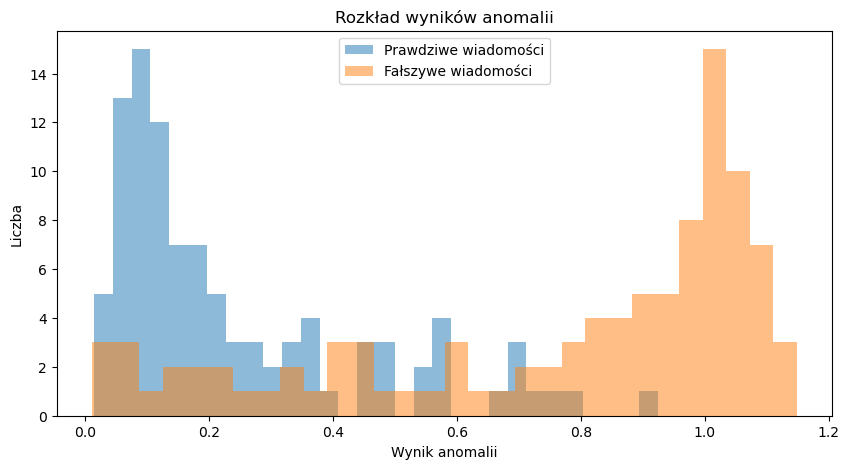

Przy użyciu progu 0.3972:
Fałszywy wskaźnik pozytywny (prawdziwe wiadomości wykryte jako fałszywe): 0.2000
Prawdziwy wskaźnik pozytywny (fałszywe wiadomości wykryte jako fałszywe): 0.8200
Gotowe!


In [17]:
# Komórka 16: Testowanie detekcji anomalii i wykres
sample_size = min(100, real_embeds.size(0), fake_embeds.size(0))
real_scores = detect_anomaly(real_embeds[:sample_size], generator, discriminator)
fake_scores = detect_anomaly(fake_embeds[:sample_size], generator, discriminator)
plt.figure(figsize=(10, 5))
plt.hist(real_scores, bins=30, alpha=0.5, label='Prawdziwe wiadomości')
plt.hist(fake_scores, bins=30, alpha=0.5, label='Fałszywe wiadomości')
plt.xlabel('Wynik anomalii'); plt.ylabel('Liczba')
plt.legend(); plt.title('Rozkład wyników anomalii')
plt.show()
threshold = np.percentile(real_scores, 80) 
real_detected = (real_scores > threshold).mean()
fake_detected = (fake_scores > threshold).mean()
print(f"Przy użyciu progu {threshold:.4f}:")
print(f"Fałszywy wskaźnik pozytywny (prawdziwe wiadomości wykryte jako fałszywe): {real_detected:.4f}")
print(f"Prawdziwy wskaźnik pozytywny (fałszywe wiadomości wykryte jako fałszywe): {fake_detected:.4f}")
print("Gotowe!")

In [19]:

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 1. Tworzymy etykiety: 0 = real, 1 = fake
y_true = np.concatenate([np.zeros_like(real_scores), np.ones_like(fake_scores)])
# 2. Tworzymy predykcje na podstawie threshold
y_pred = np.concatenate([ (real_scores  > threshold).astype(int),
                          (fake_scores  > threshold).astype(int) ])


accuracy  = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall    = recall_score(y_true, y_pred)
f1        = f1_score(y_true, y_pred)


print(f"Threshold = {threshold:.4f}")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")


Threshold = 0.3972
Accuracy : 0.8100
Precision: 0.8039
Recall   : 0.8200
F1-score : 0.8119
